Umbralización binaria y binaria inversa

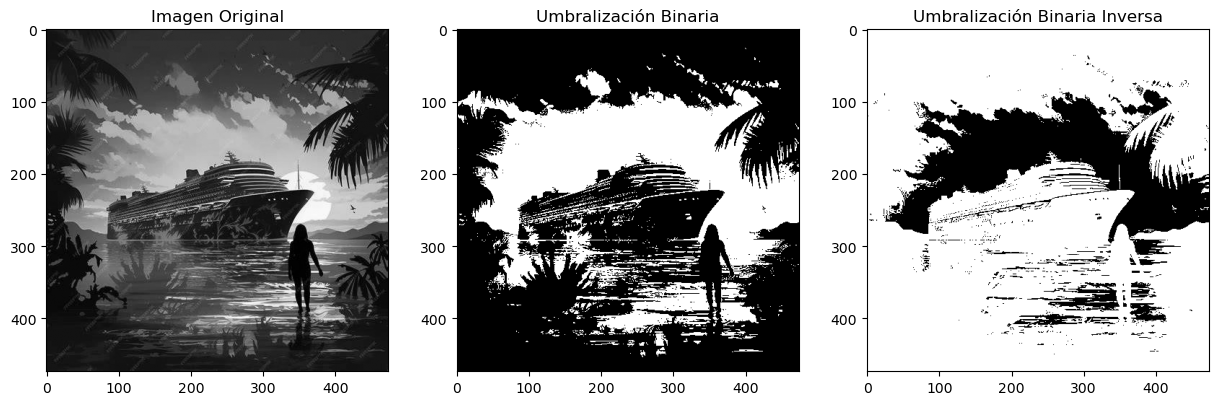

In [1]:
import cv2
import matplotlib.pyplot as plt
imagen = cv2.imread('img3.png',0) #Lee la imagen en escala de grises
# Umbralización binaria
_, umbral_binario = cv2.threshold(imagen, 90, 255, cv2.THRESH_BINARY)
# Umbralización binaria inversa
_, umbral_binario_inv = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV)
# Mostrar las imágenes
fig, axs = plt.subplots(1, 3, figsize=(15, 7))
axs[0].imshow(imagen, cmap='gray')
axs[0].set_title('Imagen Original')
axs[1].imshow(umbral_binario, cmap='gray')
axs[1].set_title('Umbralización Binaria')
axs[2].imshow(umbral_binario_inv, cmap='gray')
axs[2].set_title('Umbralización Binaria Inversa')
plt.show()

--------------------------
Umbralización global: Isodata
--------------------------

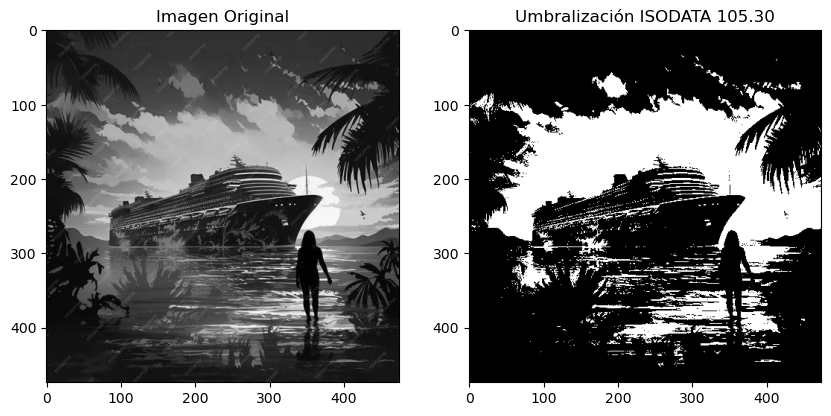

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def isodata(image):
    #decidimos umbral inicial de 0 a 255
    umbral = 128 #puedo cambiarlo cuando se requiera
    while True:
        #separamos en dos grupos
        grupo1 = image[image <= umbral] # grupo deonde el umbral es menor o igual al valor determinado
        grupo2 = image[image > umbral] # menor al determinado
        #calculamos las medias de cada grupo
        media1 = np.mean(grupo1) #if len(grupo1) > 0 else 0
        media2 = np.mean(grupo2) #if len(grupo2) > 0 else 0
        #calculamos nuevo umbral
        nuevo_umbral = (media1 + media2) / 2
        #verificamos si el umbral ha convergido al valor inicial (si vuelve a ser igual se detiene)
        if abs(nuevo_umbral - umbral) < 0.5: #tolerancia de 0.5
            break
        umbral = nuevo_umbral
    return umbral

imagen = cv2.imread('img3.png', 0) # Leer la imagen en escala de grises
umbral_isodata = isodata(imagen)
_, umbralizacion_isodata = cv2.threshold(imagen, umbral_isodata, 255, cv2.THRESH_BINARY)
# Mostrar las imágenes
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(imagen, cmap='gray')
axs[0].set_title('Imagen Original')
axs[1].imshow(umbralizacion_isodata, cmap='gray')
axs[1].set_title(f'Umbralización ISODATA {umbral_isodata:.2f}')
plt.show()

--------------------------
Umbralización global: de 2 picos
--------------------------

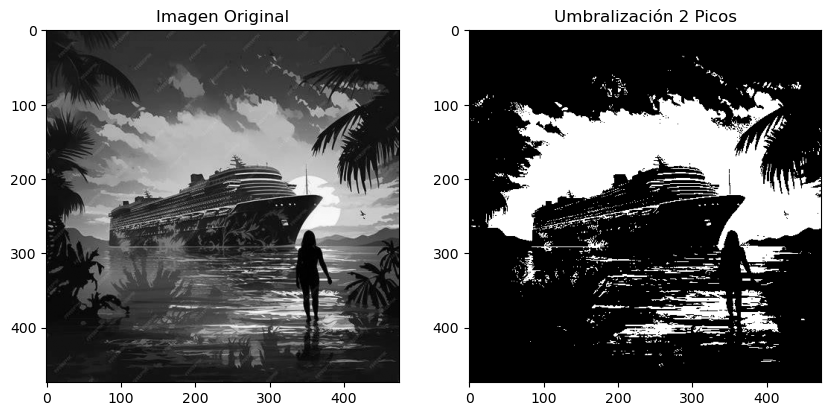

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dos_picos(image):
    # Calcular el histograma
    hist = cv2.calcHist([image], [0], None, [256], [0, 256])
    # Encontrar los 2 picos en el histograma
    pico = np.array(hist).flatten()
    pico_dif = np.diff(pico) # Diferencia entre los picos del histograma
    primer_pico = np.argmax(pico_dif[:100]) # Primer pico hasta 127
    segundo_pico = np.argmax(pico_dif[100:]) + 100 # Segundo pico de 128 para arriba
    # Calcular el umbral como el punto medio entre los dos picos
    umbral = (primer_pico + segundo_pico) / 2
    return umbral

imagen = cv2.imread('img3.png', 0)
umbral_2_picos = dos_picos(imagen)
_, umbralizacion_2_picos = cv2.threshold(imagen, umbral_2_picos, 255, cv2.THRESH_BINARY)
# Mostrar las imágenes
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(imagen, cmap='gray')
axs[0].set_title('Imagen Original')
axs[1].imshow(umbralizacion_2_picos, cmap='gray')
axs[1].set_title('Umbralización 2 Picos')
plt.show()

--------------------------
Umbralización OTSU
--------------------------

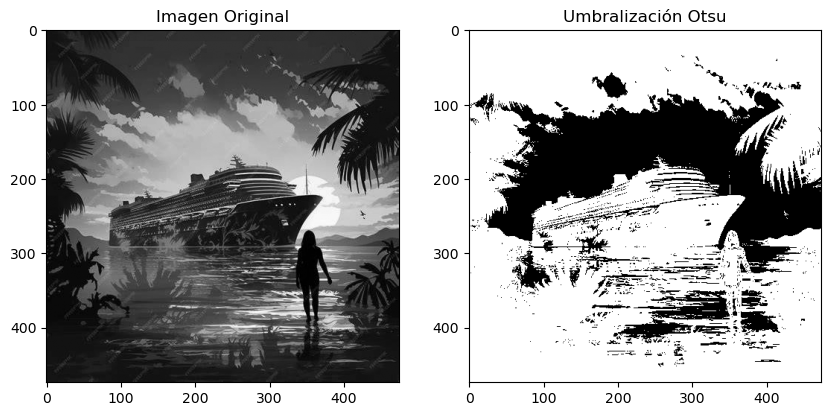

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('img3.png', 0)
#se pueden combinar diferentes umbralizaciones, en este caso se le dice a opencv que calcule 
# el umbral óptimo usando Otsu y luego aplique la umbralización binaria
_, otsu = cv2.threshold(imagen, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU) 
#aplicamos el umbral calculado por Otsu para obtener la imagen final umbralizada
imagen_fin = np.where(imagen > otsu, 255, 0).astype(np.uint8)

# Mostrar las imágenes
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(imagen, cmap='gray')
axs[0].set_title('Imagen Original')
axs[1].imshow(imagen_fin, cmap='gray')
axs[1].set_title('Umbralización Otsu')
plt.show()


--------------------------
Umbralización Variable: Partición de una imagen
--------------------------

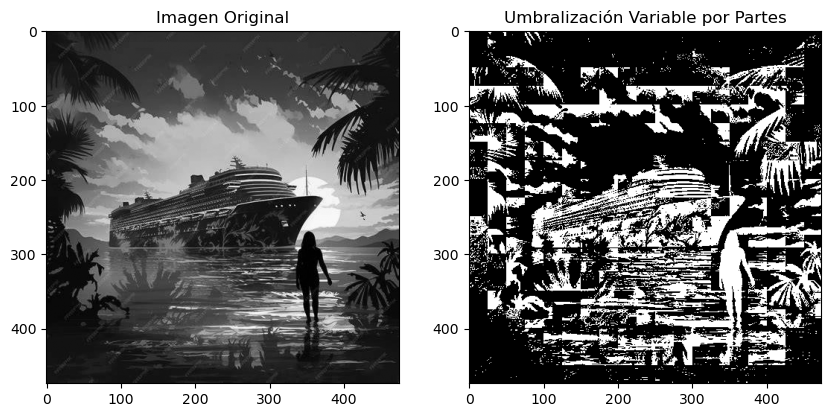

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def variable_part(image, tam_bloque, c):
    umbral_img = np.zeros_like(image)
    for y in range(0, image.shape[0], tam_bloque): #recorremos filas
        for x in range(0, image.shape[1], tam_bloque): #recorremos columnas
            bloque = image[y:y+tam_bloque, x:x+tam_bloque] #obtenemos el bloque de la imagen
            bloq_media = np.mean(bloque) #intensidad del bloque
            umbral = bloq_media - c #calculamos el umbral restando una constante a la media del bloque
            umbral_img[y:y+tam_bloque, x:x+tam_bloque] = (bloque > umbral) + 255 # umbral binaria
    return umbral_img

tam_bloque = 25
c = 10
imagen = cv2.imread('img3.png', 0)
img_fin = variable_part(imagen, tam_bloque, c)
# Mostrar las imágenes
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(imagen, cmap='gray')
axs[0].set_title('Imagen Original')
axs[1].imshow(img_fin, cmap='gray')
axs[1].set_title('Umbralización Variable por Partes')
plt.show()

--------------------------
Umbralización Variable: Propiedades locales
--------------------------

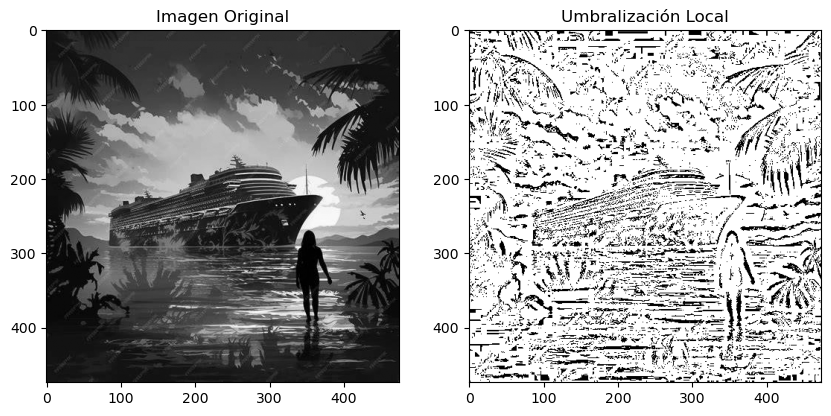

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('img3.png', 0) # escala de grises

def local(image, tam_ventana, k):
    umbral_img = np.zeros_like(image)
    #definir un rastreo de imagen con padding
    pad = tam_ventana // 2
    #agregamos un borde a la imagen para evitar problemas en los bordes al calcular la ventana
    padded_image = cv2.copyMakeBorder(image, pad, pad, pad, pad, cv2.BORDER_REPLICATE) 
    for y in range(image.shape[0]):
        for x in range(image.shape[1]):
            ventana = padded_image[y:y+tam_ventana, x:x+tam_ventana] #obtenemos la ventana centrada en el píxel actual
            media_local = np.mean(ventana) #calculamos la media de la ventana
            std_mean = np.std(ventana) #calculamos la desviación estándar de la ventana
            umbral = media_local - (k * std_mean) #calculamos el umbral restando una constante a la media de la ventana
            umbral_img[y, x] = 255 if image[y, x] > umbral else 0 #umbral binaria
    return umbral_img

tam_ventana = 15
k = 0.7
img_local = local(imagen, tam_ventana, k)

# Mostrar las imágenes
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(imagen, cmap='gray')
axs[0].set_title('Imagen Original')
axs[1].imshow(img_local, cmap='gray')
axs[1].set_title('Umbralización Local')
plt.show()


--------------------------
Umbralización Variable con OpenCV
--------------------------

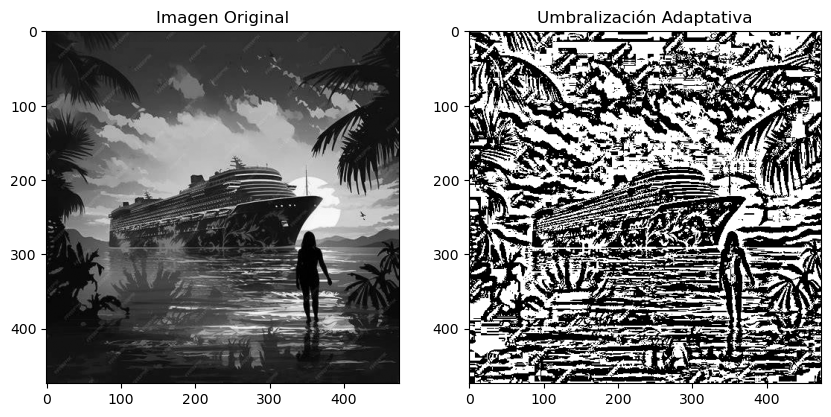

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('img3.png', 0) # escala de grises

ventana = 15
k = 0.7
imagen_fin = cv2.adaptiveThreshold(imagen, 255, cv2.ADAPTIVE_THRESH_MEAN_C, cv2.THRESH_BINARY, ventana, k)

# Mostrar las imágenes
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(imagen, cmap='gray')
axs[0].set_title('Imagen Original')
axs[1].imshow(imagen_fin, cmap='gray')
axs[1].set_title('Umbralización Adaptativa')
plt.show()

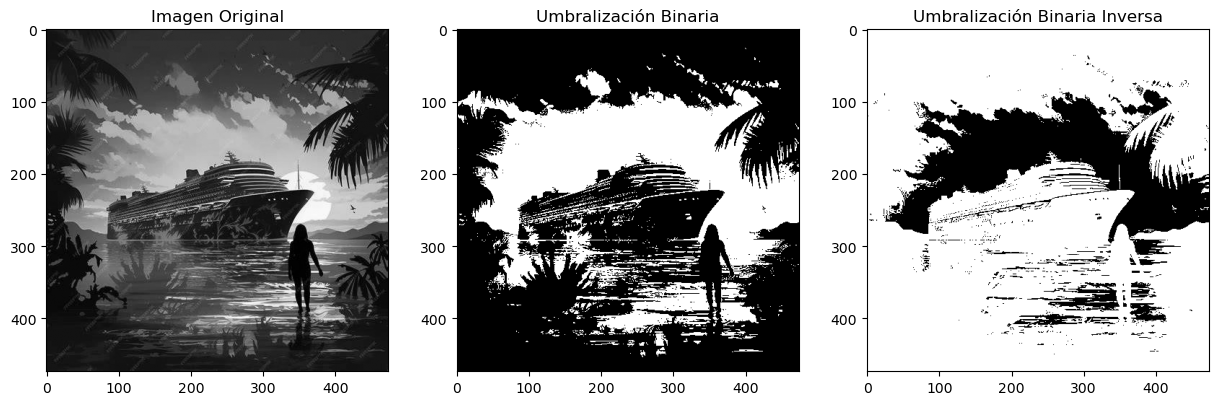

In [8]:
import cv2
import matplotlib.pyplot as plt
imagen = cv2.imread('img3.png',0) #Lee la imagen en escala de grises
# Umbralización binaria
_, umbral_binario = cv2.threshold(imagen, 90, 255, cv2.THRESH_BINARY)
# Umbralización binaria inversa
_, umbral_binario_inv = cv2.threshold(imagen, 127, 255, cv2.THRESH_BINARY_INV)
# Mostrar las imágenes
fig, axs = plt.subplots(1, 3, figsize=(15, 7))
axs[0].imshow(imagen, cmap='gray')
axs[0].set_title('Imagen Original')
axs[1].imshow(umbral_binario, cmap='gray')
axs[1].set_title('Umbralización Binaria')
axs[2].imshow(umbral_binario_inv, cmap='gray')
axs[2].set_title('Umbralización Binaria Inversa')
plt.show()